In [23]:
import os
import numpy as np
import glob
import PIL.Image as Image

#!pip install torchsummary
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
from torchvision import models
from torchsummary import summary
import torch.optim as optim
from time import time
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [24]:
from typing import List, Tuple, Optional

In [25]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [ ]:
data_path = '/dtu/datasets1/02516/PH2_Dataset_images/'

def generate_box(label, padding_ratio=0.0):
    label = label.squeeze(0)
    height, width = label.shape
    positive_labels = torch.nonzero(label)

    # 如果没有找到正样本区域，则返回全零掩码
    if positive_labels.size(0) == 0:
        return torch.zeros_like(label).unsqueeze(0)

    # 计算原始的边界框
    min_y, min_x = torch.min(positive_labels, dim=0).values
    max_y, max_x = torch.max(positive_labels, dim=0).values

    # 如果边界框已经覆盖了整个图像，则返回全一掩码
    if min_y == 0 and min_x == 0 and max_y == height - 1 and max_x == width - 1:
        return torch.ones_like(label).unsqueeze(0)

    # 计算要扩大的像素数量
    padding_y = int((max_y - min_y) * padding_ratio)
    padding_x = int((max_x - min_x) * padding_ratio)

    # 在边界框基础上添加噪声（扩大区域）
    min_y = max(min_y - padding_y, 0)
    min_x = max(min_x - padding_x, 0)
    max_y = min(max_y + padding_y, height - 1)
    max_x = min(max_x + padding_x, width - 1)

    # 生成扩大的边界框掩码
    box_mask = torch.zeros_like(label)
    box_mask[min_y:max_y+1, min_x:max_x+1] = 1

    return box_mask.unsqueeze(0)
# Loaded 130 training images
# Loaded 30 val images
# Loaded 40 test images
class PH2(torch.utils.data.Dataset):
    def __init__(self, type, transform, data_path=data_path, img_size = 128, padding_ratio = 0.0):
        'Initialization'
        self.transform = transform
        image_paths = sorted(glob.glob(data_path + '/*/*_Dermoscopic_Image/*.bmp'))
        label_paths = sorted(glob.glob(data_path + '/*/*_lesion/*.bmp'))
        # idx = int(len(image_paths) * 0.8)
        total_samples = len(image_paths)
        train_end_idx = int(0.7 * total_samples)
        val_end_idx = int(0.85 * total_samples)

        if type == 'train':
            self.image_paths = image_paths[:train_end_idx]
            self.label_paths = label_paths[:train_end_idx]
        elif type == 'val':
            self.image_paths = image_paths[train_end_idx:val_end_idx]
            self.label_paths = label_paths[train_end_idx:val_end_idx]
        elif type == 'test':
            self.image_paths = image_paths[val_end_idx:]
            self.label_paths = label_paths[val_end_idx:]

        self.box_labels = torch.zeros((len(self.image_paths), 1, img_size, img_size), dtype=torch.float32)
        self.padding_ratio = padding_ratio

    def __len__(self):
        'Returns the total number of samples'
        return len(self.image_paths)

    def __getitem__(self, idx):
        'Generates one sample of data'
        image_path = self.image_paths[idx]
        label_path = self.label_paths[idx]

        image = Image.open(image_path)
        label = Image.open(label_path)
        Y = self.transform(label)
        X = self.transform(image)
        box_labels = self.box_labels[idx]

        if box_labels.sum() == 0:
            self.box_labels[idx] = generate_box(Y, self.padding_ratio)

        return X, self.box_labels[idx], Y
    def update_box_labels(self, new_labels):
        self.box_labels = new_labels.clone()


In [27]:
size = 128
train_transform = transforms.Compose([transforms.Resize((size, size)),
                                    transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((size, size)),
                                    transforms.ToTensor()])

train_size = 130;
val_size = 30;
batch_size = 6
trainset = PH2(type='train', transform=train_transform)
valset = PH2(type='val', transform=train_transform)
testset = PH2(type='test', transform=test_transform)
train_loader = DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=3,
)
val_loader = DataLoader(
    valset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=3,
)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=3)


print('Loaded %d training images' % len(trainset))
print('Loaded %d val images' % len(valset))
print('Loaded %d test images' % len(testset))

Loaded 140 training images
Loaded 30 val images
Loaded 30 test images


Generating...


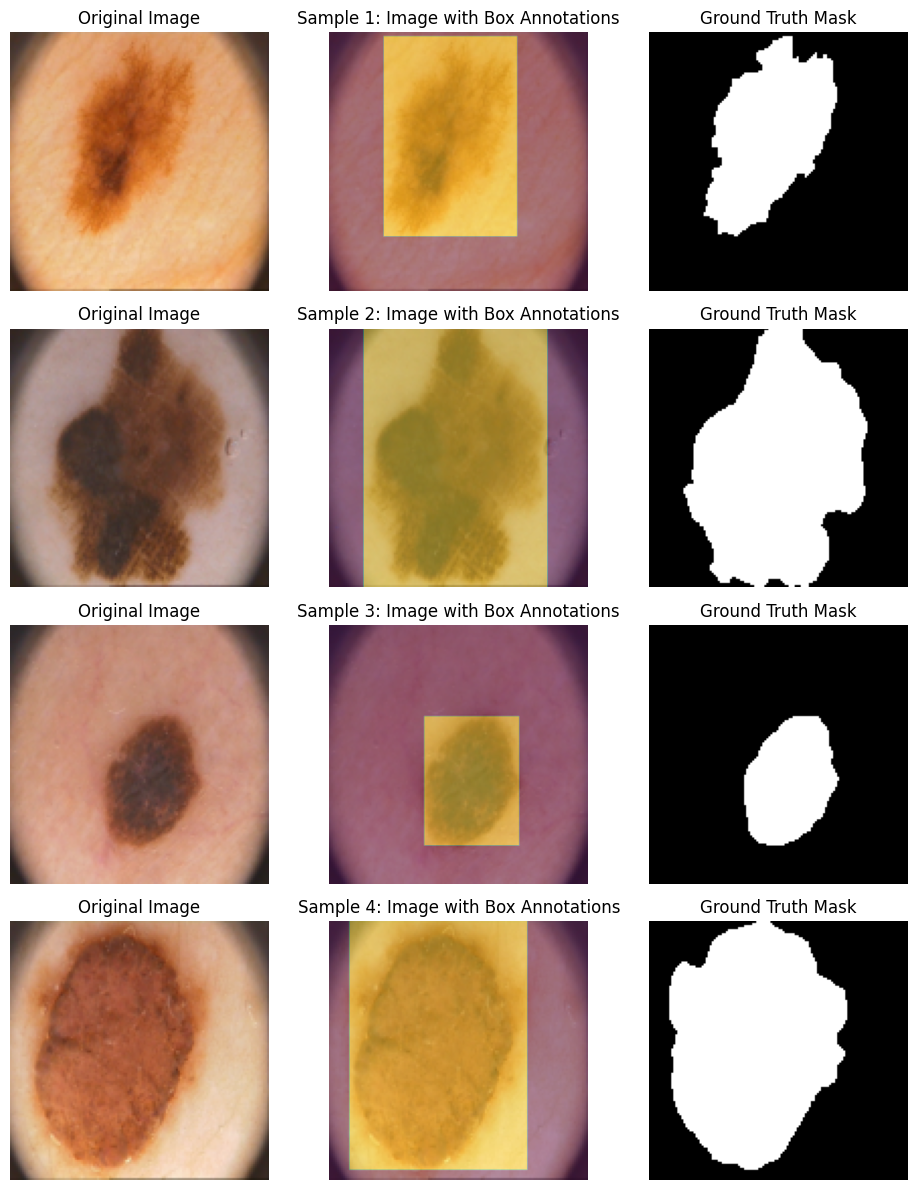

In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
import torch.nn.functional as F

def visualize_batch(dataloader, num_samples=6):
    """
    Visualize a batch of data from the point supervision dataloader

    Args:
        dataloader: DataLoader with point supervision
        num_samples: Number of samples to visualize
    """
    # Get a batch of data
    X, box_labels, Y = next(iter(dataloader))

    # Take only the first num_samples
    X = X[:num_samples]
    Y = Y[:num_samples]
    labels = box_labels[:num_samples]

    # Create figure
    fig, axes = plt.subplots(num_samples, 3, figsize=(10, 3*num_samples))

    for i in range(num_samples):
        # Original image
        img = X[i].permute(1, 2, 0).numpy()
        # Normalize image for visualization if needed
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)
        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Original Image')
        axes[i, 0].axis('off')

        # point in image
        axes[i, 1].imshow(img)
        label = labels[i].squeeze()
        axes[i, 1].imshow(label, alpha=0.4)


        # axes[i, 1].legend()
        axes[i, 1].set_title(f'Sample {i+1}: Image with Box Annotations')
        axes[i, 1].axis('off')


        # Ground truth mask
        mask = Y[i, 0].numpy()
        axes[i, 2].imshow(mask, cmap='gray')
        axes[i, 2].set_title('Ground Truth Mask')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()



# Example usage:
def preview_batch(train_loader, num_samples=4):

    print("Generating...")
    visualize_batch(train_loader, num_samples)

preview_batch(train_loader)

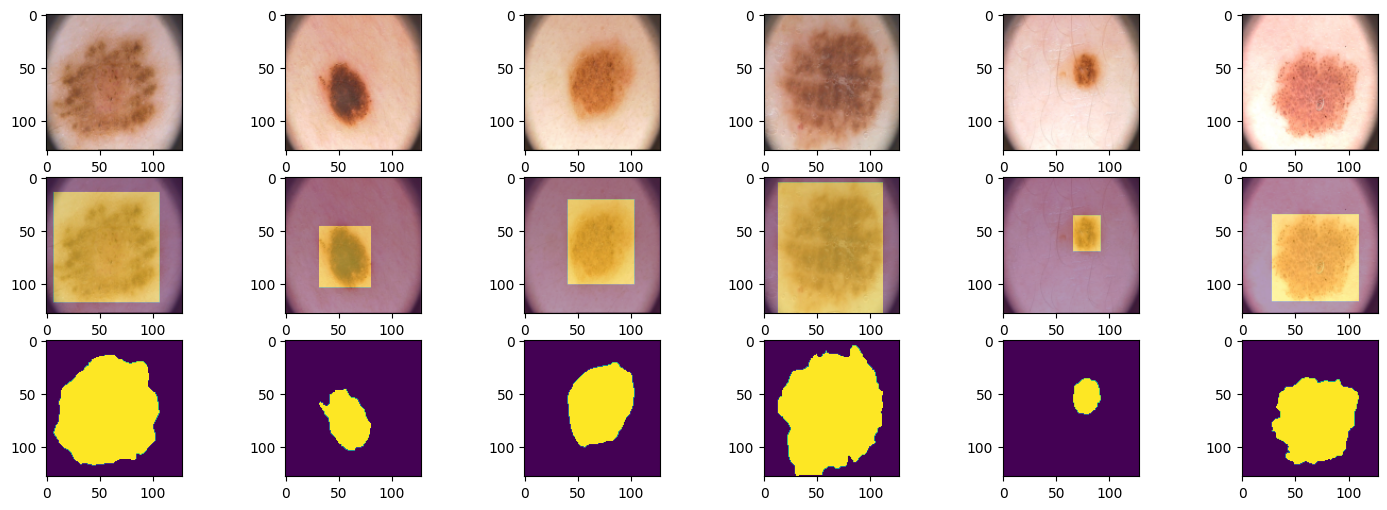

In [29]:
plt.rcParams['figure.figsize'] = [18, 6]

images, box_labels, labels = next(iter(train_loader))

for i in range(6):
    plt.subplot(3, 6, i+1)
    plt.imshow(np.swapaxes(np.swapaxes(images[i], 0, 2), 0, 1))
    plt.subplot(3, 6, i+7)
    plt.imshow(np.swapaxes(np.swapaxes(images[i], 0, 2), 0, 1))
    plt.imshow(box_labels[i].squeeze(), alpha=0.4)
    plt.subplot(3, 6, i+13)
    plt.imshow(labels[i].squeeze())
plt.show()

In [30]:
#device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [31]:
#指标函数
def dice_coefficient(pred, target, epsilon=1e-6):
    pred = (pred > 0.5).float()
    target = (target > 0.5).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()
    dice = (2. * intersection + epsilon) / (union + epsilon)
    return dice

def iou(pred, target, epsilon=1e-6):
    pred = (pred > 0.5).float()
    target = (target > 0.5).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + epsilon) / (union + epsilon)
    return iou

def accuracy(pred, target):
    pred = (pred > 0.5).float()
    target = (target > 0.5).float()

    correct = (pred == target).sum()
    total = target.numel()
    return correct.float() / total

def sensitivity(pred, target, epsilon=1e-6):
    pred = (pred > 0.5).float()
    target = (target > 0.5).float()

    TP = ((pred == 1) & (target == 1)).sum()
    FN = ((pred == 0) & (target == 1)).sum()
    return TP.float() / (TP + FN + epsilon)

def specificity(pred, target, epsilon=1e-6):
    pred = (pred > 0.5).float()
    target = (target > 0.5).float()

    TN = ((pred == 0) & (target == 0)).sum()
    FP = ((pred == 1) & (target == 0)).sum()
    return TN.float() / (TN + FP + epsilon)

In [32]:
class UNet(nn.Module):
   def __init__(self):
      super(UNet, self).__init__()
      # Encoder (downsampling)
      self.enc_conv0 = nn.Conv2d(3, 16, 3, padding=1) # Input: (512, 512) -> (512, 512) with 16 channels
      self.pool0 = nn.MaxPool2d(2, 2) # 512 -> 256

      self.enc_conv1 = nn.Conv2d(16, 32, 3, padding=1) # 256 -> 256
      self.pool1 = nn.MaxPool2d(2, 2) # 256 -> 128

      self.enc_conv2 = nn.Conv2d(32, 64, 3, padding=1) # 128 -> 128
      self.pool2 = nn.MaxPool2d(2, 2) # 128 -> 64

      self.enc_conv3 = nn.Conv2d(64, 128, 3, padding=1) # 64 -> 64
      self.pool3 = nn.MaxPool2d(2, 2) # 64 -> 32

      # Bottleneck
      self.bottleneck_conv = nn.Conv2d(128, 256, 3, padding=1) # 32 -> 32

      # Decoder (upsampling + conv)
      self.up_conv0 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2) # 32 -> 64
      self.dec_conv0 = nn.Conv2d(256, 128, 3, padding=1) # concatenated with enc_conv3

      self.up_conv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2) # 64 -> 128
      self.dec_conv1 = nn.Conv2d(128, 64, 3, padding=1) # concatenated with enc_conv2

      self.up_conv2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2) # 128 -> 256
      self.dec_conv2 = nn.Conv2d(64, 32, 3, padding=1) # concatenated with enc_conv1

      self.up_conv3 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2) # 256 -> 512
      self.dec_conv3 = nn.Conv2d(32, 16, 3, padding=1) # concatenated with enc_conv0

      # Final output layer
      self.final_conv = nn.Conv2d(16, 1, 1) # 1x1 conv layer to output 1 channel for binary segmentation

   def forward(self, x):
      # Encoder
      e0 = F.relu(self.enc_conv0(x)) # 512 -> 512 with 16 channels
      e0_p = self.pool0(e0) # Pooling: 512 -> 256
      e1 = F.relu(self.enc_conv1(e0_p)) # 256 -> 256 with 32 channels
      e1_p = self.pool1(e1) # Pooling: 256 -> 128
      e2 = F.relu(self.enc_conv2(e1_p)) # 128 -> 128 with 64 channels
      e2_p = self.pool2(e2) # Pooling: 128 -> 64
      e3 = F.relu(self.enc_conv3(e2_p)) # 64 -> 64 with 128 channels
      e3_p = self.pool3(e3) # Pooling: 64 -> 32
      # Bottleneck
      b = F.relu(self.bottleneck_conv(e3_p)) # 32 -> 32 with 256 channels
      # Decoder with skip connections
      d0 = self.up_conv0(b) # 32 -> 64 with 128 channels
      d0 = torch.cat([d0, e3], dim=1) # Concatenate with encoder layer (e3)
      d0 = F.relu(self.dec_conv0(d0)) # 256 channels after concatenation

      d1 = self.up_conv1(d0) # 64 -> 128 with 64 channels
      d1 = torch.cat([d1, e2], dim=1) # Concatenate with encoder layer (e2)
      d1 = F.relu(self.dec_conv1(d1)) # 128 channels after concatenation

      d2 = self.up_conv2(d1) # 128 -> 256 with 32 channels
      d2 = torch.cat([d2, e1], dim=1) # Concatenate with encoder layer (e1)
      d2 = F.relu(self.dec_conv2(d2)) # 64 channels after concatenation

      d3 = self.up_conv3(d2) # 256 -> 512 with 16 channels
      d3 = torch.cat([d3, e0], dim=1) # Concatenate with encoder layer (e0)
      d3 = F.relu(self.dec_conv3(d3)) # 32 channels after concatenation

      # Final output layer (sigmoid can be applied in loss function for binary segmentation)
      output = self.final_conv(d3) # 64 -> 1 channel for binary segmentation

      # Add sigmoid to output for binary classification
      output = torch.sigmoid(output)
      return output

In [33]:
import cv2

def apply_top_hat(img):
    # Assuming the input img is in numpy format (H, W)
    # Create a structuring element (adjust size as needed)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    # Apply the Top-Hat transformation
    top_hat_img = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)
    return top_hat_img

def evaluate(model, loader, device, loss_fn, stage="Validation"):
    model.eval()
    dice_scores, iou_scores, acc_scores, sens_scores, spec_scores = [], [], [], [], []
    total_loss = 0
    with torch.no_grad():
        for images, _, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            loss = loss_fn(outputs, labels)  # Calculate loss
            total_loss += loss.item() / len(loader)

            preds = (outputs > 0.5).float()  # Assume a binary classification task, threshold at 0.5
            labels = (labels > 0.5).float()  # Assume a binary classification task, threshold at 0.5

            # Calculate performance metrics
            dice_scores.append(dice_coefficient(preds, labels).item())
            iou_scores.append(iou(preds, labels).item())
            acc_scores.append(accuracy(preds, labels).item())
            sens_scores.append(sensitivity(preds, labels).item())
            spec_scores.append(specificity(preds, labels).item())

    avg_dice = sum(dice_scores) / len(dice_scores)
    avg_iou = sum(iou_scores) / len(iou_scores)
    avg_acc = sum(acc_scores) / len(acc_scores)
    avg_sens = sum(sens_scores) / len(sens_scores)
    avg_spec = sum(spec_scores) / len(spec_scores)

    # Display predictions on the validation set
    X_val, _, Y_val = next(iter(loader))  # Extract a batch of data from the validation set
    X_val, Y_val = X_val.to(device), Y_val.to(device)
    Y_hat = model(X_val).detach().cpu()  # Perform prediction and move to CPU

    clear_output(wait=True)  # Clear previous output to avoid repetitive displays
    num_images_to_show = min(len(X_val), 10)  # Show up to 6 images

    plt.figure(figsize=(8, 10))  # Adjust image size, width=8, height=10, can be modified as needed
    for k in range(num_images_to_show):
        plt.subplot(5, num_images_to_show, k+1)  # Set up a 5-row grid
        plt.imshow(np.rollaxis(X_val[k].cpu().numpy(), 0, 3), cmap='gray')
        plt.title('Image')
        plt.axis('off')

        plt.subplot(5, num_images_to_show, k+num_images_to_show+1)
        # Use .squeeze() to remove single-channel dimension
        plt.imshow(Y_val[k].cpu().numpy().squeeze(), cmap='gray')
        plt.title('Mask')
        plt.axis('off')

        plt.subplot(5, num_images_to_show, k+num_images_to_show*2+1)
        # Display original prediction Y_hat
        plt.imshow((Y_hat[k].cpu().numpy().squeeze() > 0.5), cmap='gray')
        plt.title('Predict')
        plt.axis('off')

    # Adjust spacing between subplots
    plt.subplots_adjust(hspace=0.2)  # hspace adjusts row spacing, wspace adjusts column spacing
    plt.suptitle(f'{stage} Results - Loss: {total_loss:.4f}')
    plt.show()
    return total_loss, avg_dice, avg_iou, avg_acc, avg_sens, avg_spec

In [34]:
def update_box_labels(model, train_dataset):
    model.eval()  # 设置模型为评估模式
    new_box_labels = []
    original_dataset = train_dataset.dataset if isinstance(train_dataset, torch.utils.data.Subset) else train_dataset
    with torch.no_grad():
        for i in range(len(train_dataset)):
            image, _, _ = train_dataset[i]
            image = image.unsqueeze(0).to(device)

            Y_pred = model(image)

            # 将概率图转换为二值掩码（例如，阈值化处理）
            Y_pred_binary = (Y_pred > 0.5).float().cpu().squeeze(0)
            new_box_labels.append(Y_pred_binary)

    new_box_labels = torch.stack(new_box_labels)
    original_dataset.update_box_labels(new_box_labels)
    return new_box_labels

def draw_bounding_boxes(images, box_labels, num_images=6, figsize=(18, 5)):
    plt.figure(figsize=figsize)

    for i in range(num_images):
        image = images[i].permute(1, 2, 0).cpu().numpy()  # 转换为 HWC 形状的 NumPy 数组
        label = box_labels[i, 0].cpu().squeeze().numpy()  # 提取单通道的伪标签

        # 绘制图像
        ax = plt.subplot(1, num_images, i + 1)
        ax.imshow(image)
        ax.imshow(label, cmap='gray', alpha=0.5)  # 使用半透明显示标签
        ax.axis('off')  # 去除坐标轴

    plt.tight_layout()
    plt.show()

# 训练函数
def train(model, opt, loss_fn, epochs, train_loader, device):
    model.to(device)  # 将模型移动到指定设备上

    # 记录每个 epoch 的训练损失和验证损失
    train_losses = []
    val_losses = []

    max_val_dice = 0
    max_val_iou = 0
    max_val_acc = 0
    max_val_sens = 0
    max_val_spec = 0
    sample_images, _, _ = next(iter(train_loader))
    sample_indices = torch.arange(6)
    print(sample_indices)
    for it in range(5):

        sample_images, sample_labels, _ = zip(*[train_loader.dataset[i] for i in sample_indices])
        sample_images = torch.stack(sample_images)
        sample_labels = torch.stack(sample_labels).clone()
        draw_bounding_boxes(sample_images, sample_labels)

        model.train()
        for epoch in range(epochs):
            # print(f'* Iteration: {it+1} Epoch {epoch+1}/{epochs}')
            avg_loss = 0

            model.train()  # 模型设为训练模式
            for X_batch, Y_batch, _ in train_loader:
                X_batch = X_batch.to(device)
                Y_batch = Y_batch.to(device)

                # 清除以前的梯度
                opt.zero_grad()

                # 前向传播
                Y_pred = model(X_batch)
                loss = loss_fn(Y_pred, Y_batch)  # 计算损失
                loss.backward()  # 反向传播
                opt.step()  # 更新模型权重
                avg_loss += loss.item() / len(train_loader)  # 累积损失

            train_losses.append(avg_loss)  # 记录当前 epoch 的训练损失
            # print(f' - Training Loss: {avg_loss:.4f}')
        # 每次迭代计算一次验证损失
        # val_loss, val_dice, val_iou, val_acc, val_sens, val_spec= evaluate(model, val_loader, device, loss_fn, stage="Validation")
        # max_val_dice = max(val_dice, max_val_dice)
        # max_val_iou = max(val_iou, max_val_iou)
        # max_val_acc = max(val_acc, max_val_acc)
        # max_val_sens = max(val_sens, max_val_sens)
        # max_val_spec = max(val_spec, max_val_spec)
        # val_losses.append(val_loss)  # 记录当前 epoch 的验证损失
        # # outputs.append(f"max:  epoch: {epoch} Dice: {max_val_dice:.4f}, IoU: {max_val_iou:.4f}, Acc: {max_val_acc:.4f}, Sens: {max_val_sens:.4f}, Spec: {max_val_spec:.4f}")
        # print(f"Validation: epoch: {epoch} Loss: {val_loss:.4f}, Dice: {val_dice:.4f}, IoU: {val_iou:.4f}, Acc: {val_acc:.4f}, Sens: {val_sens:.4f}, Spec: {val_spec:.4f}")
        # print(f"max:  epoch: {epoch} Dice: {max_val_dice:.4f}, IoU: {max_val_iou:.4f}, Acc: {max_val_acc:.4f}, Sens: {max_val_sens:.4f}, Spec: {max_val_spec:.4f}")

        train_dataset = train_loader.dataset
        # 每次训练完更新 label
        update_box_labels(model, train_dataset)


    sample_images, sample_labels, _ = zip(*[train_loader.dataset[i] for i in sample_indices])
    sample_images = torch.stack(sample_images)
    sample_labels = torch.stack(sample_labels).clone()
    draw_bounding_boxes(sample_images, sample_labels)
    # 在训练结束后，绘制训练损失和验证损失的曲线
    # plt.figure(figsize=(10, 5))
    # plt.plot(train_losses, label='Training Loss')
    # plt.plot(range(0, epochs), val_losses, label='Validation Loss')
    # plt.xlabel('Epoch')
    # plt.ylabel('Loss')
    # plt.title('Training and Validation Loss Over Epochs')
    # plt.legend()
    # plt.show()

def validate(model, val_loader, device, loss_fn):
    val_loss, val_dice, val_iou, val_acc, val_sens, val_spec = evaluate(model, val_loader, device, loss_fn, stage="Validation")
    print(f"Validation: Loss: {val_loss:.4f}, Dice: {val_dice:.4f}, IoU: {val_iou:.4f}, Acc: {val_acc:.4f}, Sens: {val_sens:.4f}, Spec: {val_spec:.4f}")

# # test
def test(model, test_loader, device, loss_fn):
    # evaluate on the test set
    test_loss, test_dice, test_iou, test_acc, test_sens, test_spec = evaluate(model, test_loader, device, loss_fn, stage="Test")
    print(f"Test Results: Loss: {test_loss:.4f}, Dice: {test_dice:.4f}, IoU: {test_iou:.4f}, "
          f"Acc: {test_acc:.4f}, Sens: {test_sens:.4f}, Spec: {test_spec:.4f}")

In [35]:
def focal_loss(y_pred, y_real):
    gamma = 2
    y_real = y_real.float().view(-1)
    y_pred = y_pred.view(-1)
    epsilon = 1e-6

    focal_weights = (1 - y_pred) ** gamma
    l = -(focal_weights * y_real * torch.log(y_pred + epsilon) + (1 - y_real) * torch.log(1 - y_pred + epsilon))
    return torch.mean(l)
loss_fn = focal_loss
# loss_fn = nn.BCELoss()

In [36]:
model_EncDec = UNet().to(device)

tensor([0, 1, 2, 3, 4, 5])


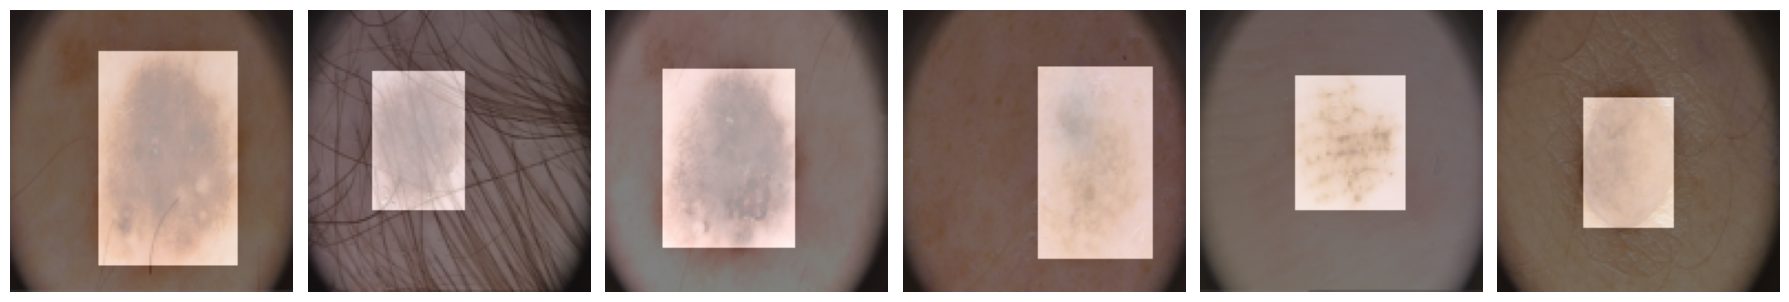

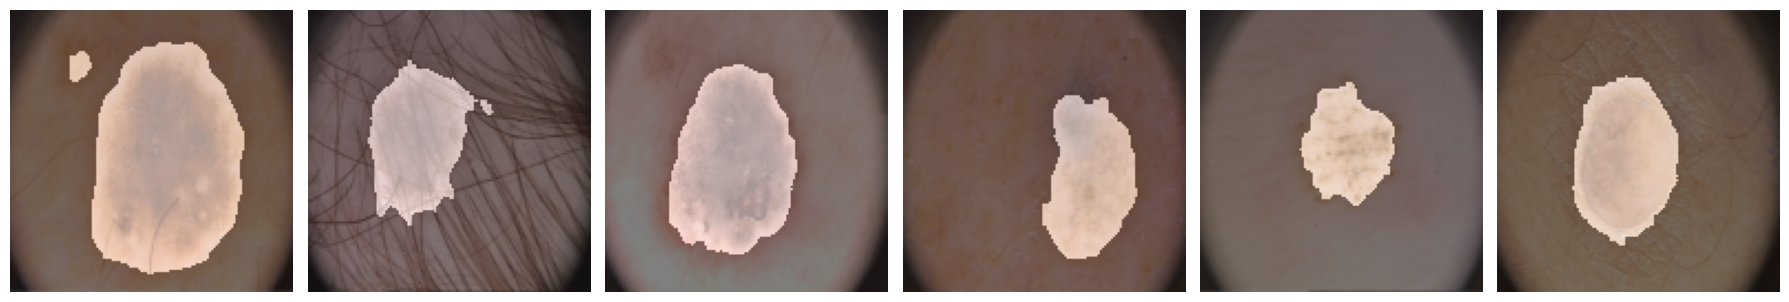

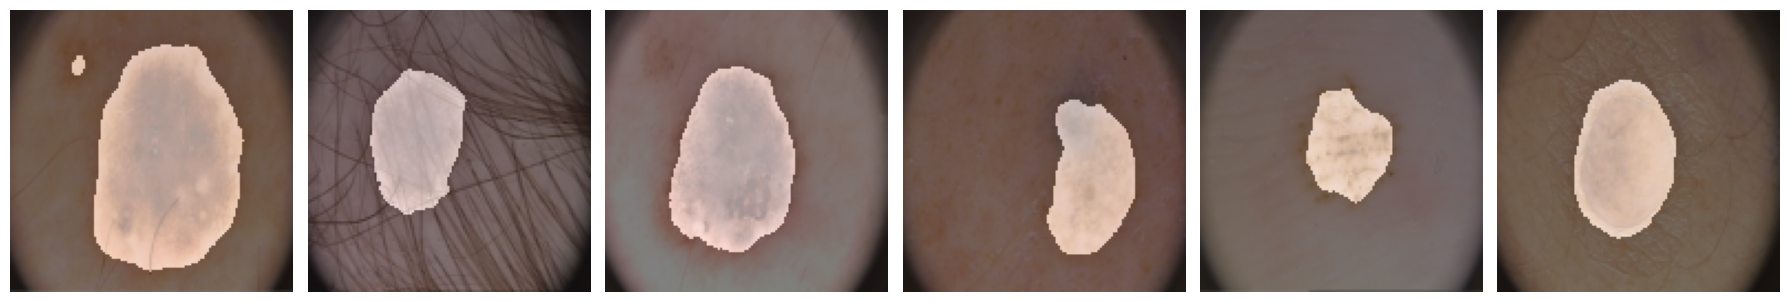

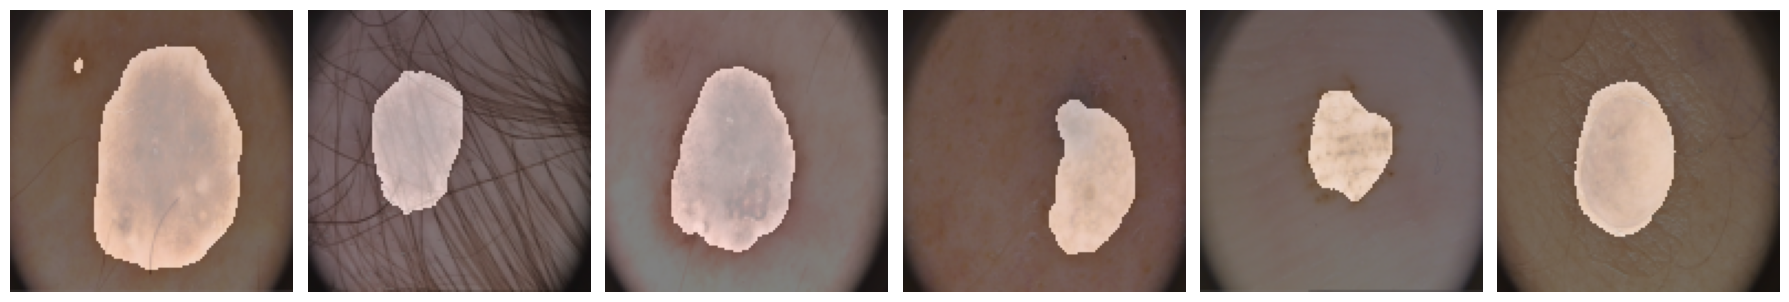

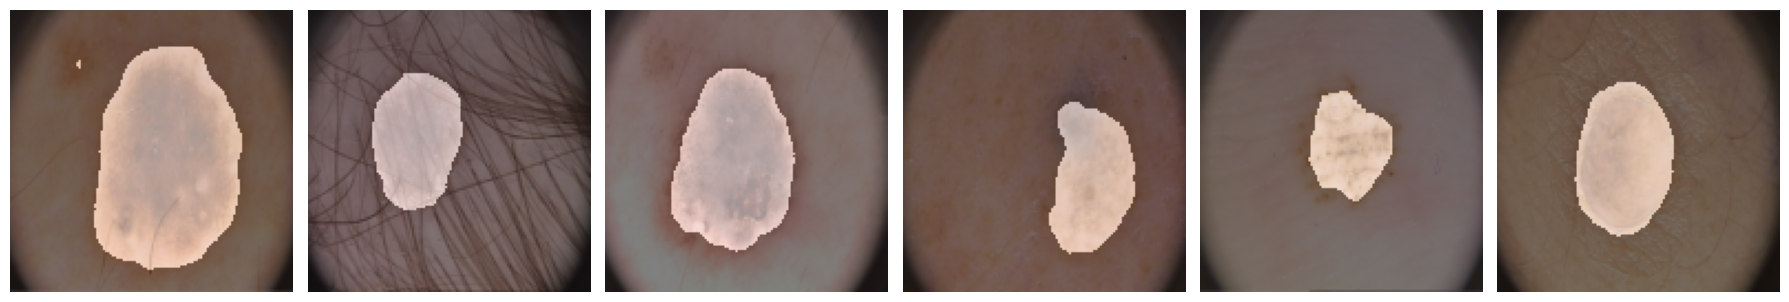

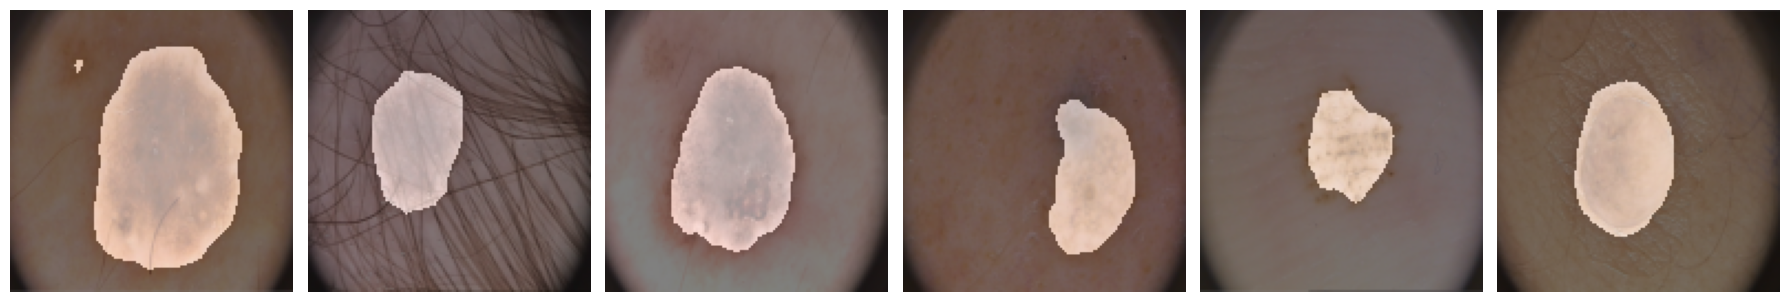

In [37]:

outputs = []
train(
    model=model_EncDec,
    opt=optim.Adam(model_EncDec.parameters(), lr=0.001),
    loss_fn=loss_fn,
    epochs=10,
    train_loader=train_loader,
    device=device
)

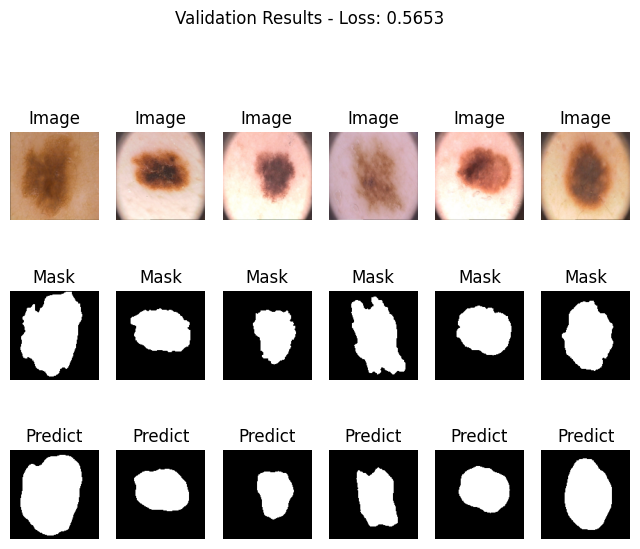

Validation: Loss: 0.5653, Dice: 0.8597, IoU: 0.7561, Acc: 0.9251, Sens: 0.8302, Spec: 0.9713


In [38]:
validate(
    model=model_EncDec,
    loss_fn=loss_fn,
    val_loader=val_loader,
    device=device
)

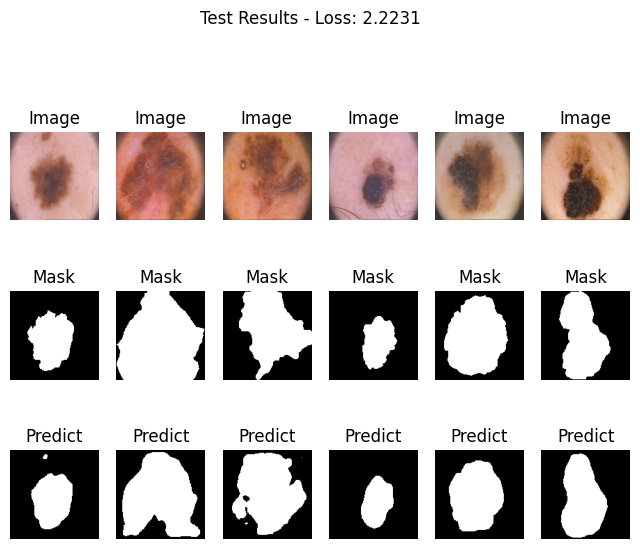

Test Results: Loss: 2.2231, Dice: 0.7737, IoU: 0.6373, Acc: 0.7802, Sens: 0.6501, Spec: 0.9829


In [39]:
test(
    model=model_EncDec,
    loss_fn=loss_fn,
    test_loader=test_loader,
    device=device
)